In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

In [3]:
FILE_PATH = Path.cwd().parent / "datasets" / "winequality-red.csv"

In [ ]:
try:
    df = pd.read_csv(FILE_PATH,sep=";") # file is not csv but ssv
except FileNotFoundError :
    print("Unable to find the file path !!!\nPlease enter a valid file path")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
else:
    print(" Dataset loaded successfully")

 Dataset loaded successfully


In [15]:
df.shape

(1599, 12)

In [17]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [18]:
# Initial thoughts : Every NUMERIC column is not on same scale , we would need to use a scaler to normalize these values

In [20]:
df.info() # A really clean dataset and on top of that all numerical values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [21]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [22]:
# Most of the cirtic acid column values are closer to 0 i think as the mean is 0.27 considering the max is 1
# Similar observation for other preceeding cols as well

In [23]:
# We need to plot these into graphs for better evaluation

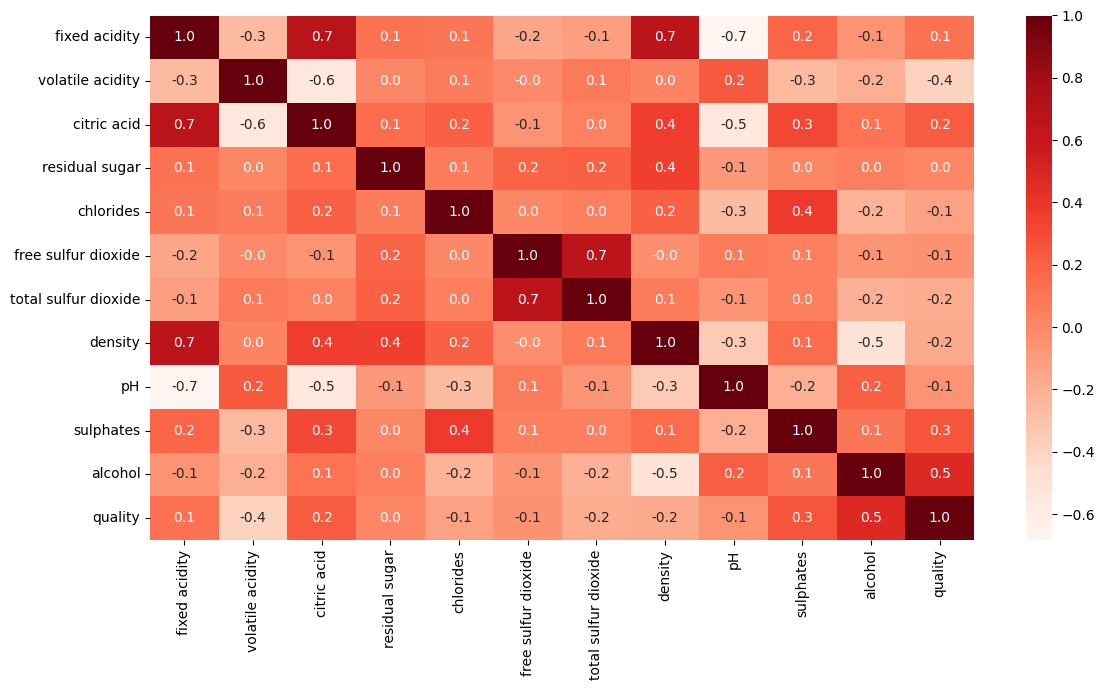

In [30]:
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(),cmap="Reds",annot=True,fmt=".1f")
plt.tight_layout()
plt.show()

In [33]:
# As we clearly see there are some cols of sulfur dioxide and fixed density relating to other cols causing multicollinearity.
# Let's clear this up with doing the VIF test

# VIF for feature :  How much can that feature be predicted using other features 
# The more the value means the more features contribute to that feature 

In [ ]:
# Standard testing libraries 
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Make sure to have a dataset with correlation factors.
df

# 2. Add an intercept column (CRITICAL for accurate VIF metrics)
X = sm.add_constant(df)

# 3. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# 4. Display results (Excluding the constant row from final evaluation)
print(vif_data[vif_data["Feature"] != 'const'])

                 Feature       VIF
1          fixed acidity  7.772051
2       volatile acidity  1.879663
3            citric acid  3.131055
4         residual sugar  1.703859
5              chlorides  1.500591
6    free sulfur dioxide  1.968010
7   total sulfur dioxide  2.214467
8                density  6.346491
9                     pH  3.339511
10             sulphates  1.487286
11               alcohol  3.238899
12               quality  1.563848


In [ ]:
# Looks like we have to deal with fixed acidity as  :
""" 
VIF : fixed acidity > 5 : Warrants attention. Standard errors are slightly inflated.
"""

In [34]:
# What we will first do is drop the density column now and re run the tests above to look for any improvements

In [35]:
df_1 = df.drop(columns=['density'])

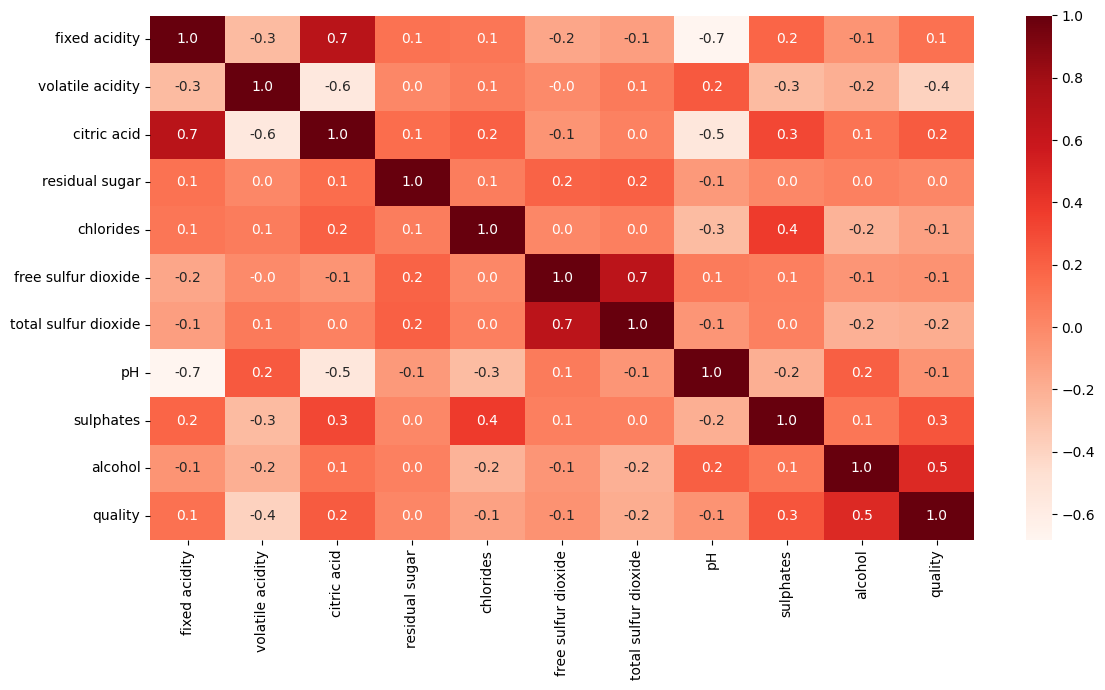

In [36]:
plt.figure(figsize=(12,7))
sns.heatmap(df_1.corr(),cmap="Reds",annot=True,fmt=".1f")
plt.tight_layout()
plt.show()

In [37]:
X_d = sm.add_constant(df_1)

# 3. Calculate VIF for each feature
vif_data_1 = pd.DataFrame()
vif_data_1["Feature"] = X_d.columns
vif_data_1["VIF"] = [variance_inflation_factor(X_d.values, i) for i in range(X_d.shape[1])]

# 4. Display results (Excluding the constant row from final evaluation)
print(vif_data_1[vif_data_1["Feature"] != 'const'])

                 Feature       VIF
1          fixed acidity  2.975973
2       volatile acidity  1.852268
3            citric acid  3.130857
4         residual sugar  1.099815
5              chlorides  1.488196
6    free sulfur dioxide  1.954036
7   total sulfur dioxide  2.201691
8                     pH  2.253940
9              sulphates  1.396431
10               alcohol  1.532875
11               quality  1.563175


In [38]:
# No fixed acidity  2.975973 < 5 that means we can use this subset for our model prediction

In [ ]:
df_1 = df # Save for backup
df = df.drop(columns=['density'])